# Chapter 2 — 用图说话：数据可视化

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chaosfrey-arch/news-classification-tutorial/blob/main/chapter02_visualization.ipynb)

**本章目标：** 画出数据分布图，用眼睛理解数据集的特征。

> 📖 参考：[matplotlib 官方教程](https://matplotlib.org/stable/tutorials/index.html)

## 2.1 为什么要可视化？

看这组数字：32037, 32028, 32018, 32017

你能一眼看出什么规律吗？

现在看图：（见下方柱状图）

**一图胜千言。** 可视化能让你在几秒内发现：
- 数据是否平衡？
- 有没有异常值？
- 各类别之间的差距有多大？

## 2.2 matplotlib 是什么？

**matplotlib** 是 Python 最基础的画图库，几乎所有 Python 图表都基于它。

我们主要用 `matplotlib.pyplot`（简称 `plt`），把它想象成一个画板：
- `plt.figure()` = 新建一张画布
- `plt.bar()` / `plt.hist()` = 在画布上画图
- `plt.show()` = 把画布展示出来

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 设置中文字体（Colab 默认不支持中文，用这行解决）
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# 加载数据
df = pd.read_csv('dataset.csv')
print('数据加载完成，共', len(df), '行')

数据加载完成，共 128600 行


## 2.3 柱状图：各类别的文章数量

Class
Science/Tech    32037
Sports          32028
World           32018
Business        32017
Name: count, dtype: int64


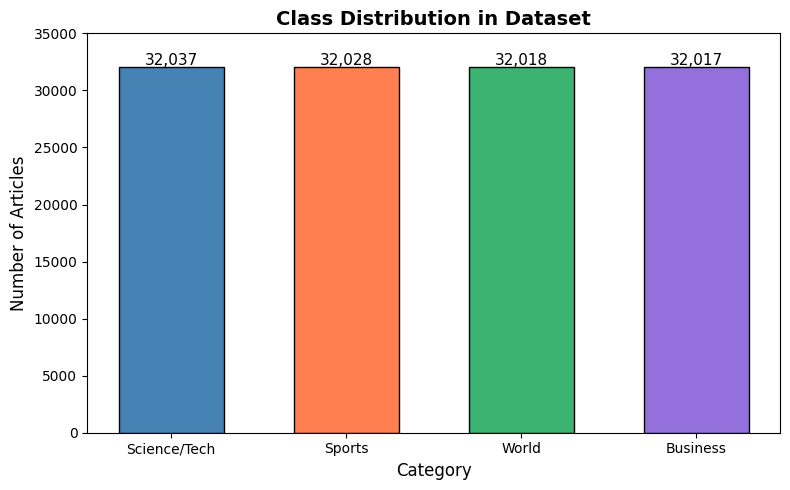


结论：四个类别几乎完全平衡，每类约 32,000 篇，差异 < 0.1%


In [3]:
# 统计各类别数量
counts = df['Class'].value_counts()
print(counts)

# ── 画柱状图 ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))  # 创建画布，指定大小（英寸）

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.6)

# 在每根柱子上方标注数字
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,  # x 坐标：柱子中心
            bar.get_height() + 200,             # y 坐标：柱子顶部往上一点
            f'{val:,}',                          # 显示的文字，加千位分隔符
            ha='center', fontsize=11)

# 标签和标题
ax.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_ylim(0, 35000)  # y 轴范围

plt.tight_layout()  # 自动调整间距，防止标签被截断
plt.show()

print('\n结论：四个类别几乎完全平衡，每类约 32,000 篇，差异 < 0.1%')

## 2.4 类别平衡的重要性

**平衡（Balanced）** 数据集：每个类别的样本数量差不多。✅

**不平衡（Imbalanced）** 数据集的问题举例：
- 假设有 99,000 条「正常邮件」和 1,000 条「垃圾邮件」
- 如果模型学到「所有邮件都说是正常邮件」，准确率高达 99%
- 但它完全没有学会识别垃圾邮件！

我们的数据集非常平衡，这是个好消息 🎉

## 2.5 直方图：文章长度分布

In [7]:
# 合并 Title + Description，计算总词数
df['Description'] = df['Description'].fillna('')
df['text'] = df['Title'] + ' ' + df['Description']
df['word_count'] = df['text'].str.split().str.len()

print(f'词数统计：')
print(df['word_count'].describe().round(1))
print(f'\n95% 的文章词数 ≤ {df["word_count"].quantile(0.95):.0f} 个词')
print(f'99% 的文章词数 ≤ {df["word_count"].quantile(0.99):.0f} 个词')

词数统计：
count    128600.0
mean         37.8
std          10.2
min           2.0
25%          32.0
50%          37.0
75%          43.0
max         177.0
Name: word_count, dtype: float64

95% 的文章词数 ≤ 53 个词
99% 的文章词数 ≤ 70 个词


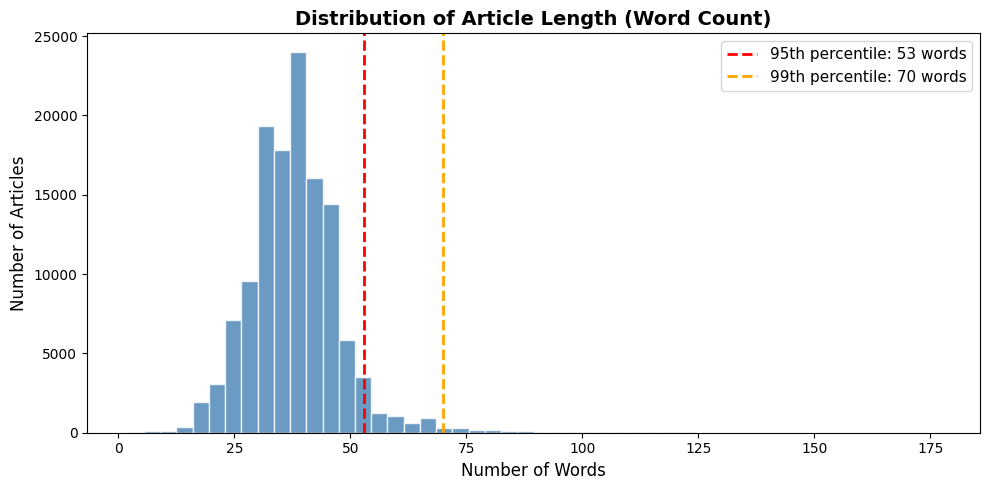

结论：大多数文章在 20-60 词之间，非常短。
这个信息告诉我们：神经网络的输入序列长度设为 100 足够覆盖 99% 的文章。


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

# 画直方图：bins 决定分成多少段
ax.hist(df['word_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)

# 标注百分位线
for pct, label, color in [(0.95, '95th percentile', 'red'), (0.99, '99th percentile', 'orange')]:
    val = df['word_count'].quantile(pct)
    ax.axvline(val, color=color, linestyle='--', linewidth=2, label=f'{label}: {val:.0f} words')

ax.set_title('Distribution of Article Length (Word Count)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Words', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('结论：大多数文章在 20-60 词之间，非常短。')
print('这个信息告诉我们：神经网络的输入序列长度设为 100 足够覆盖 99% 的文章。')

## 2.6 分组对比：各类别的文章长度

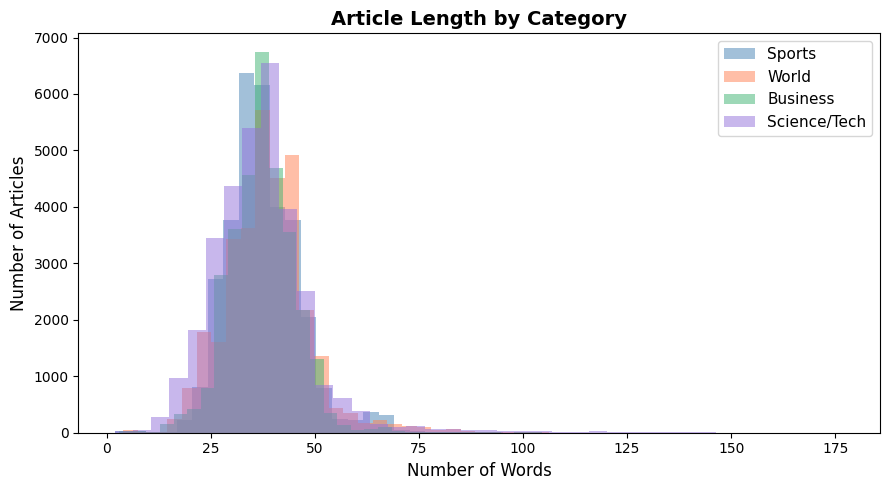

结论：四个类别的文章长度分布几乎一致，不存在某类文章特别长的情况。


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for i, cls in enumerate(df['Class'].dropna().unique()):
    subset = df[df['Class'] == cls]['word_count']
    ax.hist(subset, bins=40, alpha=0.5, color=colors[i % 4], label=cls)

ax.set_title('Article Length by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Words', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('结论：四个类别的文章长度分布几乎一致，不存在某类文章特别长的情况。')

## 🏋️ 小练习

/tmp/ipykernel_8726/410921441.py:17: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8726/410921441.py:17: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8726/410921441.py:17: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8726/410921441.py:17: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8726/410921441.py:17: UserWarning: Glyph 24352 (\N{CJK UNIFIED IDEOGRAPH-5F20}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8726/410921441.py:17: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8726/410921441.py:17: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missi

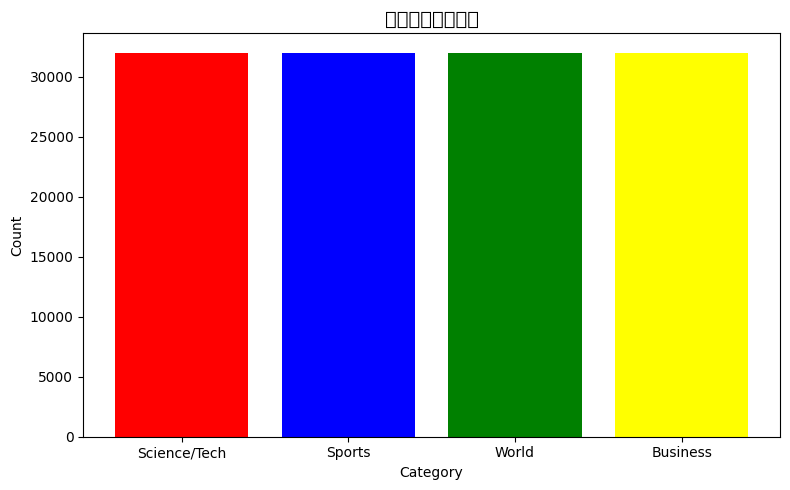

In [10]:
# 练习：修改柱状图的颜色为你喜欢的颜色，并改变标题
# 颜色可以用名称（'red', 'blue'）或十六进制（'#FF5733'）

counts = df['Class'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

# 修改这里的颜色：
my_colors = ['red', 'blue', 'green', 'yellow']  # 换成你喜欢的颜色

ax.bar(counts.index, counts.values, color=my_colors)

# 修改这里的标题：
ax.set_title('我的第一张图表！', fontsize=14)
ax.set_xlabel('Category')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 总结

| 图表类型 | 代码 | 用途 |
|---------|------|------|
| 柱状图 | `ax.bar(x, y)` | 对比不同类别的数量 |
| 直方图 | `ax.hist(data, bins=n)` | 查看数值的分布 |
| 竖线 | `ax.axvline(x)` | 标注特殊值（如百分位数）|
| 图例 | `ax.legend()` | 解释每条线/每个颜色的含义 |

**核心发现：**
1. 数据集完全平衡（好事！）
2. 文章普遍较短（中位数约 37 词）
3. MAX_LEN=100 能覆盖 99% 的文章

**下一章 →** Chapter 3：文本预处理